<a href="https://colab.research.google.com/github/MiksterBerlin/BRFSS_MH/blob/This%26That/Copy_of_MH_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Depression Prediction Model**

The Behavioral Risk Factor Surveillance System (BRFSS) is an annual survey that is led by the Centers for Disease Control and Prevention (CDC) and applied in collaboration with the states and US territories.

BRFSS’s objective is to collect answers to a core of questions related to health risk behaviors, chronic diseases and conditions, access to health care, and use of preventive health services related to the leading causes of death and disability. States can select a number of elective modules to collect state-specific data on top of the annual core module. BRFSS conducts both landline and mobile phone-based surveys with individuals over the age of 18. General factors assessed by the BRFSS in 2021 included health status and healthy days, exercise, insufficient sleep, chronic health conditions, oral health, tobacco use, cancer screenings, and access to healthcare.

Survey data has been published annually by the [CDC](https://www.cdc.gov/) since 1984. You can find the [original dataset](https://www.cdc.gov/brfss/annual_data/annual_2021.html) as a ASCII format and past years data from [here](https://www.cdc.gov/brfss/annual_data/annual_data.htm).

The aim of this project is to build a model to predict mental health outcomes that could serve as a tool to prevent these outcomes from happening.
The data contains information about 6735 unique survey participants.



## **Importing of tools**

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay, roc_curve, auc, precision_score, recall_score

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.impute import SimpleImputer


# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [8]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
pd.set_option('display.max_columns', 500)

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Uploading SAS datasets into Colab for processing

# Replace 'path/to/your/file.sas7bdat' with the actual path to your SAS file.
# If on Google Drive, it might look like '/content/drive/My Drive/your_folder/your_file.sas7bdat'
file_path = '/content/drive/My Drive/brfs_21p.sas7bdat'

try:
    df = pd.read_sas(file_path)
    print("SAS file successfully loaded into a pandas DataFrame.")
    print(df.head()) # Display the first few rows of the DataFrame
except UnicodeDecodeError:
    print("Encoding error detected. Attempting with Latin-1 encoding.")
    df = pd.read_sas(file_path, encoding='latin-1')
    print("SAS file successfully loaded with Latin-1 encoding.")
    print(df.head())
except FileNotFoundError:
    print(f"Error: File not found at {file_path}. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

SAS file successfully loaded into a pandas DataFrame.
   _STATE  _GEOSTR  _DENSTR2    REPNUM  REPDEPTH  FMONTH         DATE  CP_MN  \
0     6.0    206.0       2.0  123226.0       1.0    12.0  b'01042022'  b'01'   
1     6.0    206.0       1.0  123850.0      24.0    12.0  b'01042022'  b'01'   
2     6.0    202.0       2.0  123932.0      23.0    12.0  b'01042022'  b'01'   
3     6.0    206.0       2.0  123952.0      18.0    12.0  b'01062022'  b'01'   
4     6.0    202.0       1.0  124206.0       7.0    12.0  b'01052022'  b'01'   

   CP_DY    CP_YR          _PSU  NRECSEL       NRECSTR  NUMADULT  NUMMEN  \
0  b'04'  b'2022'  2.021006e+09  25498.0  1.715263e+07      99.0     NaN   
1  b'04'  b'2022'  2.021006e+09  25498.0  1.715263e+07       1.0     NaN   
2  b'04'  b'2022'  2.021006e+09  19895.0  1.250960e+07       1.0     NaN   
3  b'06'  b'2022'  2.021006e+09  25498.0  1.715263e+07       2.0     NaN   
4  b'05'  b'2022'  2.021006e+09  19895.0  1.250960e+07       2.0     NaN   

   NUMWO

## **Reading Data and Selecting The Variables**

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6735 entries, 0 to 6734
Columns: 514 entries, _STATE to SHMHWHERE2TXT
dtypes: float64(498), object(16)
memory usage: 26.4+ MB


In [12]:
df.describe()

,_STATE,_GEOSTR,_DENSTR2,REPNUM,REPDEPTH,FMONTH,_PSU,NRECSEL,NRECSTR,NUMADULT,NUMMEN,NUMWOMEN,GENHLTH,PHYSHLTH,MENTHLTH,POORHLTH,TYPPLAN1,PERSDOC1,NOMED1,CHECKUP2,EXERANY1,BPHIGH3,BPMED,CHOLCHK3,TOLDHI1,CHOLMED3,HEART2,ANGINA,STROKE2,ASTHEVE3,ASTHNOW,SKCANC,OTHCANC,COPDEVER,DEPRESS1,KIDNEY,DIABCOR3,DIABAGE,ARTHRITD,ARTHEXER,ARTHEDU,LIMITJN2,ARTHWRK2,ARTHPAIN,AGE,ORACE3A,MARITAL,EDUCAC,OWNHOME,NUMHOLD2,NUMPHON4,CELL17,MILITAR2,EMPLOY2,CHILD18,INCOM03,PREGNANT,WEIGHT,HEIGHT,DEAF,BLIND,REMEM2,DIFFWALK,DIFDRES2,DIFFERND,SMOKE100,SMKEVDA2,USENOW3,ECIGEVDA,DRNKALC2,NALCOCC3,DRNKGE5B,DRINKNUM,FLUSHOT7,FLSHTWH4,FLUPLAC6,PNEUMVC4,AIDSTST9,TSTDATE,FRUIT17,JUICE17,VEGGRE17,POTATO17,OTHTATO17,OTHRVE17,PREDMBGT,PREDIAB2,COVIDVAC,COVACGET,COVIDNUM,COVIDINT,COVIDFST,COVIDSEC,CAREGIV6,CAREREALB,CARELONG,CAREHOUR1,CAREPROB1,CRGVALZD,CRGVPERS,CRGVHOUS,CRGVEXPT,HAVEGUN2,LOADED7,LOCKED7,CH_SEL,RCSBRAC1,CH_REL,CHLDAST2,CHLDASTB,SEX2,TRNSGNDR,VERSION,_URBNRRL,_METSTAT,_URBSTAT,MSCODE,_STSTR,_STRWT,_RAW,_WT2,_RAWRAKE,_WT2RAKE,_REGION,_IMPSEX,_IMPAGE,_IMPRACE,_IMPNPH,_IMPCTY,_IMPEDUC,_IMPMRTL,_IMPHOME,O_STATE,_CHISPNC,CRACASC1,_CRACE1,_CPRACE1,_IMPCAGE,_IMPCRAC,_IMPCSEX,_RAWCH,_WT2CH,CHILDAGE,_CLCPM01,_CLCPM02,_CLCPM03,_CLCPM04,_CLCPM05,_CLLCPWT,_CLCM1V1,_CLCM2V1,_CLCM3V1,_CLCM4V1,_CLCM5V1,_CLCWTV1,_CLCM1V2,_CLCM2V2,_CLCM3V2,_CLCM4V2,_CLCM5V2,_CLCWTV2,_CLCM1V3,_CLCM2V3,_CLCM3V3,_CLCM4V3,_CLCM5V3,_CLCWTV3,_DUALUSE,_DUALCOR,_LLCPWT2,_LLCPM01,_LLCPM02,_LLCPM03,_LLCPM04,_LLCPM05,_LLCPM06,_LLCPM07,_LLCPM08,_LLCPM09,_LLCPM10,_LLCPM11,_LLCPM12,_LLCPM13,_LLCPM14,_LLCPM15,_LLCPM16,_LLCPWT,_LCM01V1,_LCM02V1,_LCM03V1,_LCM04V1,_LCM05V1,_LCM06V1,_LCM07V1,_LCM08V1,_LCM09V1,_LCM10V1,_LCM11V1,_LCM12V1,_LCPWTV1,_LCM01V2,_LCM02V2,_LCM03V2,_LCM04V2,_LCM05V2,_LCM06V2,_LCM07V2,_LCM08V2,_LCM09V2,_LCM10V2,_LCM11V2,_LCM12V2,_LCPWTV2,_LCM01V3,_LCM02V3,_LCM03V3,_LCM04V3,_LCM05V3,_LCM06V3,_LCM07V3,_LCM08V3,_LCM09V3,_LCM10V3,_LCM11V3,_LCM12V3,_LCPWTV3,_RFHLTH,_PHYS14D,_MENT14D,_HLTHPLN,_HCVU652,_TOTINDA,_RFHYPE6,_CHOLCH3,_RFCHOL3,_MICHD,_LTASTH1,_CASTHM1,_ASTHMS1,_DRDXAR3,_LMTACT3,_LMTWRK3,MRACASC1,_PRACE1,_MRACE1,_M_RACE,_HISPANC,_RACECDC,_RACEG21,_RACEGR3,_RACEPRV,_SEX,_AGEG5YR,_AGE65YR,_AGE80,_AGE_G,HTIN4,HTM4,WTKG3,_BMI5,_BMI5CAT,_RFBMI5,_CHLDCNT,_EDUCAG,_INCOMG1,_SMOKER3,_RFSMOK3,_CURECI1,DRNKANY5,_DROCDY3,_RFBING5,_DRNKWK1,_RFDRHV7,_FLSHOT7,_PNEUMO3,_AIDTST4,FTJUDA2_,FRUTDA2_,GRENDA1_,FRNCHDA_,_POTADA1,_VEGEDA2,_MISFRT1,_MISVEG1,_FRTRES1,_VEGRES1,_FRUTSU1,_VEGESU1,_FRTLT1A,_VEGLT1A,_FRT16A,_VEG23A,_FRUITE1,_VEGETE1,YEAR,SEQNOQ,SOURCE,HHSIZE,COUNTY1,COUNTY,ORACE3A_1,ORACE3A_2,ORACE3A_3,ORACE3A_4,ORACE3A_5,ORACE3A_6,ORACE3A_8,ORACE3A_9,CH_RACE3A_1,CH_RACE3A_2,CH_RACE3A_3,CH_RACE3A_4,CH_RACE3A_5,CH_RACE3A_6,CH_RACE3A_8,CH_RACE3A_9,ORACE4A,CH_RACE4A,HISPMEX,HISPPR,HISPCUB,HISPOTH,HISP4,CH_HMEX,CH_HPR,CH_HCUB,CH_HOTH,CH_HISP2,CH_BO_MO,CH_BO_YR,PARTIAL,SEQNO,BPREAD,BPHOME,DIABINS,CHKGLU1,DIABDOC2,RETINHAD,DIABCRSE,SXORIEN2,EDUCA,CHILD1,CHILD2,CHILD3,ONEMONT1,SODAPOP,SWTDRINK,WHENDNT3,LOSTETH2,GAMBLE,GAMBLE1,GAMBLE2,GAMBLE3,GAMBLE4,UNSAFEDR,PCEDIFF,PCETALK,PCESAFE,PCETRAD,PCESUPP,PCESCHL,PCEINTR,ACECARE,ACEDEPRS,ACEALC,ACEDRGS,ACEJAIL2,ACEDVRCE,ACEADLHT,ACEHTKDS,ACEINSLT,ACELOVE,ACETCHU,TSSSXEVER,TSSSXYR17,CHILD4,CHILD5,CHILD6,CHILD7,CHILD8,CHILD9,MARIJANA1,USEMRJNA18,USEMRJNA1,EATDRNKTHC,EATDRNKCBD,SMKTHC,SMKCBD,VAPETHC,VAPECBD,DABTHC,DABCBD,MARIJHIGH,MARIWHERE,MARIJCONSEQ,MJSMKHRM1,MJVAPHRM1,MJEATHRM1,MJDABHRM1,HOMEMJ,SHMEXPOS,SHMWHERE2,PKEVER,PK12MOS,PKTYPE,PKPRSCRB,PKDOCTOR,PKMISUS1,PKMISUS2,PKMISUS3,PKCURUSE,PKREASBGN,PKREASON12,PKALCO,PKBENZO,PKMETH,PKCOCA,PKCANNAB,HEREVER,HER12MOS,FENTEVER,FENT12MOS,FENTPRSCRB,FENTCURUSE,COCAEVER,COCA12MOS,METHEVER,METH12MOS,STIMEVER,STIM12MOS,STIMCURUSE,STIMPRSCRB,STIMMISUSE,DSORDRUSE1,DSORDRUSE2,DSORDRUSE3,DSORDRUSE4,DSORDRUSE5,NDLSHARE,HEROHRM1,HEROHRM2,METHHRM1,METHHRM2,COCAHRM1,COCAHRM2,PKHRM1,PKHRM2,PKHRM3,STIMHRM1,STIMHRM2,STIMHRM3,THCCBD1,HERCURUSE,METHCURUSE,ONEMONT2,ONEMONT3,ONEMONT4,ONEMONT5,ONEMONT6,ONEMONT7,ONEMONT8,ONEMONT9,

In [13]:
# Selecting Variables

df_selected= df[['GENHLTH' ,  'DEPRESS1',  'POORHLTH', 'BPHIGH3', 'HEART2',      'ANGINA',       'STROKE2',      'ASTHEVE3',     'SKCANC',       'OTHCANC',      'COPDEVER',    'KIDNEY',       'DIABCOR3',   'EDUCAC',       'OWNHOME', 'MILITAR2',  'EMPLOY2',  'PREGNANT'   ,'DEAF',        'BLIND' ,'REMEM2',      'DIFFWALK',     'DIFDRES2',     'DIFFERND',  'CAREGIV6', 'HAVEGUN2', 'TRNSGNDR',     '_REGION',   '_IMPMRTL',     '_IMPHOME',   '_RFHLTH',      '_PHYS14D',     '_MENT14D',  '_RFCHOL3',   '_HLTHPLN', '_TOTINDA', '_RFHYPE6',     '_CHOLCH3' , '_SEX','_AGE_G',  '_IMPRACE',    '_BMI5CAT', '_CHLDCNT',      '_INCOMG1'      ,'_SMOKER3'     , '_RFSMOK3',   '_RFBING5', '_FRTLT1A',     'FRNCHDA_',     '_VEGLT1A'  ,    'HHSIZE',       'COUNTY1',  'SXORIEN2', 'GAMBLE',  'MARIJANA1' ,  'HEREVER', 'FENTEVER', 'COCAEVER', 'METHEVER',   'STIMEVER',  '_POVSTD']]

In [14]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6735 entries, 0 to 6734
Data columns (total 61 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   GENHLTH    6735 non-null   float64
 1   DEPRESS1   6735 non-null   float64
 2   POORHLTH   3642 non-null   float64
 3   BPHIGH3    6735 non-null   float64
 4   HEART2     6735 non-null   float64
 5   ANGINA     6735 non-null   float64
 6   STROKE2    6735 non-null   float64
 7   ASTHEVE3   6735 non-null   float64
 8   SKCANC     6735 non-null   float64
 9   OTHCANC    6735 non-null   float64
 10  COPDEVER   6735 non-null   float64
 11  KIDNEY     6735 non-null   float64
 12  DIABCOR3   6735 non-null   float64
 13  EDUCAC     6735 non-null   float64
 14  OWNHOME    6735 non-null   float64
 15  MILITAR2   6719 non-null   float64
 16  EMPLOY2    6686 non-null   float64
 17  PREGNANT   1463 non-null   float64
 18  DEAF       6493 non-null   float64
 19  BLIND      6468 non-null   float64
 20  REMEM2  

**Looking for Missing Values and Handling Them**

Since missing values are very few compared to the size of the data, there is no problem in deleting them.

In [15]:
df_selected.isna().sum()


,0
GENHLTH,0
DEPRESS1,0
POORHLTH,3093
BPHIGH3,0
HEART2,0
...,...
FENTEVER,4373
COCAEVER,4373
METHEVER,4374
STIMEVER,4377


## **Data Cleaning and Exploration**

In [18]:
df = df_selected.replace([np.nan], -1)

In [19]:
df2 = df.replace([99.0, 88.0, 77.0, 888.0, 777.0, 999.0],-1)
print(df2)

      GENHLTH  DEPRESS1  POORHLTH  BPHIGH3  HEART2  ANGINA  STROKE2  ASTHEVE3  \
0         1.0       2.0      -1.0      3.0     2.0     2.0      2.0       2.0   
1         2.0       2.0      -1.0      3.0     2.0     2.0      2.0       2.0   
2         4.0       1.0      -1.0      3.0     2.0     2.0      2.0       2.0   
3         3.0       2.0      -1.0      3.0     2.0     2.0      2.0       2.0   
4         3.0       2.0      -1.0      3.0     2.0     2.0      2.0       2.0   
...       ...       ...       ...      ...     ...     ...      ...       ...   
6730      3.0       2.0      -1.0      1.0     2.0     2.0      2.0       2.0   
6731      4.0       2.0      -1.0      1.0     2.0     2.0      2.0       2.0   
6732      2.0       2.0      -1.0      3.0     2.0     2.0      2.0       2.0   
6733      3.0       2.0       4.0      1.0     2.0     2.0      2.0       2.0   
6734      5.0       1.0      30.0      1.0     2.0     2.0      2.0       2.0   

      SKCANC  OTHCANC  COPD

## **Reocoding a few Variables**

**SEXVAR**

SEXVAR column contains participants gender information. 1 means male and 2 means female. For better reading, the column renamed as 'Gender'.

,count
_SEX,
1.0,3399
2.0,3336


<Axes: xlabel='Gender', ylabel='count'>

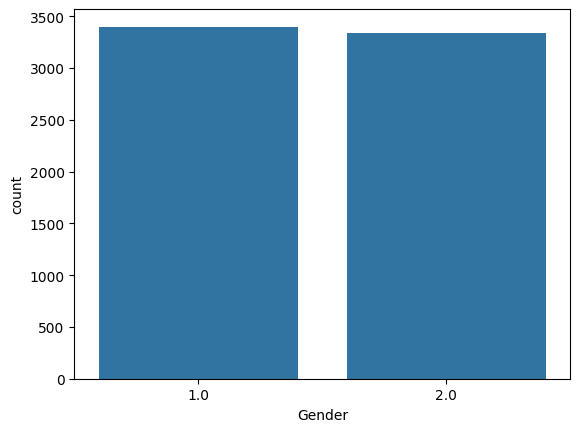

In [20]:
df2['_SEX'].value_counts()
df2 = df2.rename(columns={"_SEX":"Gender"})
sns.countplot(x='Gender', data=df2)

**\_IMPRACE**

The \_IMPRACE column contains participants race information.

* 1 means White
* 2 means Black
* 3 means Asian
* 4 means American Indian/Alaskan Native
* 5 means Hispanic
* 6 means Other race

For better reading, the column renamed as 'Race'.

,count
_IMPRACE,
1.0,3149
5.0,2242
3.0,605
2.0,343
6.0,342
4.0,54


<Axes: xlabel='Race', ylabel='count'>

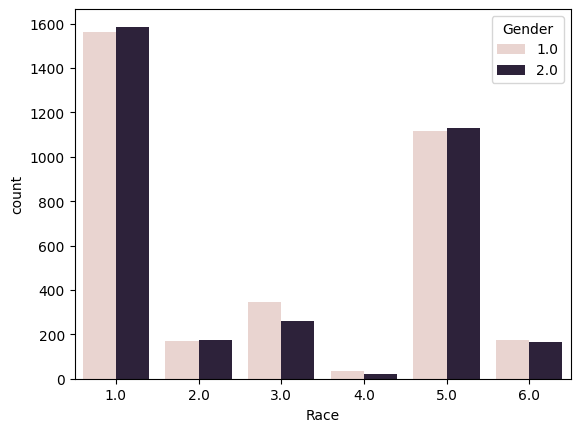

In [21]:
df2['_IMPRACE'].value_counts()
df2 = df2.rename(columns={'_IMPRACE':'Race'})
sns.countplot(x='Race', hue='Gender', data=df2)

**_AGE_G**

The _AGE_G column contains information about the age of the participants.


,count
_AGE_G,
6.0,1804
5.0,1134
2.0,1096
3.0,1083
4.0,990
1.0,628


<Axes: xlabel='Age Groups', ylabel='count'>

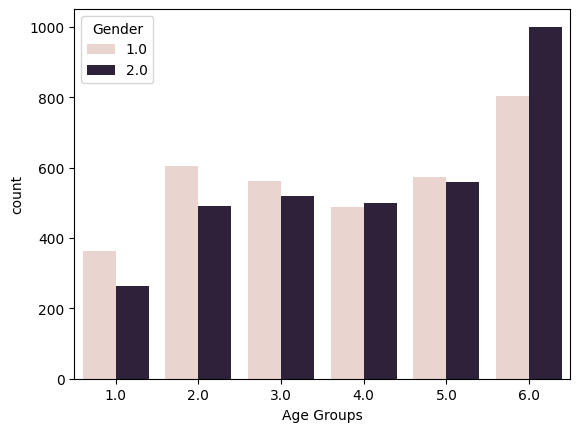

In [22]:
df2['_AGE_G'].value_counts()
df2 = df2.rename(columns={'_AGE_G':"Age Groups"})
sns.countplot(x='Age Groups', hue='Gender', data=df2)

Target Variable "Ever Diagnosed with Depression" DEPRESS1

The 'Depress1' column contains participants general health information.

* 1 Yes
* 2 No
* 99/77 missing

For better reading, the column renamed as 'Depression'.

,count
DEPRESS1,
2.0,5646
1.0,1062
-1.0,27


<Axes: xlabel='Depression', ylabel='count'>

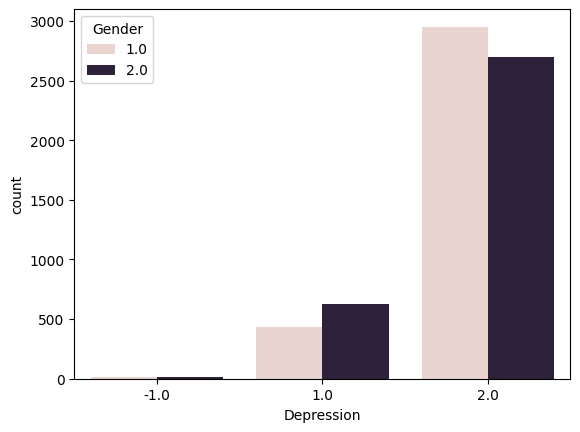

In [23]:
df2['DEPRESS1'].value_counts()
df2.drop(df2[df2['DEPRESS1'] == 99.0].index, inplace = True)
df2.drop(df2[df2['DEPRESS1'] == 77.0].index, inplace = True)
df2 = df2.rename(columns={'DEPRESS1':'Depression'})
sns.countplot(x='Depression', hue='Gender', data=df2)

In [24]:
#Subset the dataset to only include 1 = 'Yes' or 2= 'No' and exclude any other options

subset= df2[df2['Depression'].isin([1,2])]
subset.head()

,GENHLTH,Depression,POORHLTH,BPHIGH3,HEART2,ANGINA,STROKE2,ASTHEVE3,SKCANC,OTHCANC,COPDEVER,KIDNEY,DIABCOR3,EDUCAC,OWNHOME,MILITAR2,EMPLOY2,PREGNANT,DEAF,BLIND,REMEM2,DIFFWALK,DIFDRES2,DIFFERND,CAREGIV6,HAVEGUN2,TRNSGNDR,_REGION,_IMPMRTL,_IMPHOME,_RFHLTH,_PHYS14D,_MENT14D,_RFCHOL3,_HLTHPLN,_TOTINDA,_RFHYPE6,_CHOLCH3,Gender,Age Groups,Race,_BMI5CAT,_CHLDCNT,_INCOMG1,_SMOKER3,_RFSMOK3,_RFBING5,_FRTLT1A,FRNCHDA_,_VEGLT1A,HHSIZE,COUNTY1,SXORIEN2,GAMBLE,MARIJANA1,HEREVER,FENTEVER,COCAEVER,METHEVER,STIMEVER,_POVSTD
0,1.0,2.0,-1.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,6.0,2.0,2.0,2.0,-1.0,2.0,2.0,2.0,2.0,2.0,2.0,-1.0,-1.0,-1.0,6.0,5.0,2.0,1.0,2.0,2.0,-1.0,1.0,1.0,1.0,9.0,1.0,2.0,5.0,3.0,1.0,6.0,4.0,1.0,1.0,1.0,23.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0
1,2.0,2.0,-1.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,6.0,3.0,1.0,1.0,-1.0,2.0,2.0,2.0,2.0,2.0,2.0,-1.0,-1.0,-1.0,6.0,5.0,3.0,1.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,3.0,1.0,9.0,4.0,1.0,2.0,2.0,0.0,2.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0
2,4.0,1.0,-1.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,6.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,-1.0,-1.0,-1.0,2.0,5.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,3.0,2.0,1.0,6.0,4.0,1.0,1.0,1.0,100.0,1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0
3,3.0,2.0,-1.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,6.0,2.0,2.0,1.0,-1.0,2.0,2.0,2.0,2.0,2.0,2.0,-1.0,-1.0,-1.0,6.0,5.0,2.0,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,3.0,1.0,2.0,1.0,4.0,1.0,4.0,4.0,1.0,1.0,1.0,14.0,1.0,2.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,5.0
4,3.0,2.0,-1.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,4.0,6.0,1.0,2.0,1.0,-1.0,2.0,2.0,2.0,2.0,2.0,2.0,-1.0,-1.0,-1.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,3.0,4.0,7.0,3.0,1.0,2.0,2.0,14.0,1.0,2.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0


## **Preprocessing and Transforming the data**

In [44]:
#separate cathegorical and nummerical variables for processing
cathegorical_features = ['GENHLTH' , 'BPHIGH3', 'HEART2', 'ANGINA', 'STROKE2', '_CHLDCNT', 'ASTHEVE3',     'SKCANC',       'OTHCANC',      'COPDEVER',    'KIDNEY',       'DIABCOR3',   'EDUCAC',       'OWNHOME', 'MILITAR2',  'EMPLOY2',  'PREGNANT'   ,'DEAF',        'BLIND' ,'REMEM2',      'DIFFWALK',     'DIFDRES2',     'DIFFERND',  'CAREGIV6', 'HAVEGUN2', 'TRNSGNDR',     '_REGION',   '_IMPMRTL',     '_IMPHOME',   '_RFHLTH',      '_PHYS14D',     '_MENT14D', '_HLTHPLN', '_TOTINDA', '_RFHYPE6', '_CHOLCH3' , 'Gender','Age Groups',  'Race',    '_BMI5CAT', '_INCOMG1'      ,'_SMOKER3'     , '_RFSMOK3',   '_RFBING5', '_FRTLT1A',  '_VEGLT1A', 'COUNTY1',  'SXORIEN2', 'GAMBLE',  'MARIJANA1' ,  'HEREVER', 'FENTEVER', 'COCAEVER', 'METHEVER',   'STIMEVER',  '_POVSTD']
nummeric_features = ['POORHLTH' , 'HHSIZE', 'FRNCHDA_',]

In [45]:
# Select only the numeric columns for the pivot table
numeric_df = subset[nummeric_features + ['Depression']]

# Create the pivot table using only the numeric features as values
table1 = pd.pivot_table(data=numeric_df, index=['Depression'])
table1

,FRNCHDA_,HHSIZE,POORHLTH
Depression,,,
1.0,27.579096,2.265537,7.623352
2.0,17.454835,2.397450,1.277187


In [46]:
X = subset.drop(columns=['Depression'])
y = subset['Depression']

In [47]:
#Categorical features will be transformed using OneHotEncoder and nummeric features with the StandardScaler

preprocessor = make_column_transformer(
    (OneHotEncoder(), cathegorical_features),
    (StandardScaler() , nummeric_features)
)

In [48]:
pipeline = make_pipeline(preprocessor)

In [49]:
X_transformed = pipeline.fit_transform(X)

print(X_transformed.shape)

(6708, 280)


## **Predictive Modelling**

In [50]:
#Correlation matix to reduce features for analysis FULL & SHORT Dataset

from scipy.stats import pearsonr
#FULL dataset
# For simplicity, assuming it's a dense NumPy array or can be converted.
if not isinstance(X_transformed, np.ndarray):
    # Check if it's a sparse matrix before converting
    if hasattr(X_transformed, 'toarray'):
        Xtr = X_transformed.toarray() # Convert sparse matrix to dense if necessary
    # If it's neither ndarray nor sparse, print a warning or handle appropriately
    else:
        print("Warning: X is not a NumPy array or sparse matrix. Correlation might not be calculated correctly.")



# Ensure y is a NumPy array for consistent indexing, though pandas Series also works
if isinstance(y, pd.Series):
    y = y.values

# **Encode the target variable y1 to numerical values**
# Map 'yes' to 1 and 'no' to 2
y1_encoded = np.where(y == 1, 1, 2)
# Iterate through each column (feature) in Xand calculate the correlation with y1
# Assuming X has shape (n_samples, n_features)
n_features = Xtr.shape[1]

# Store results to sort later
correlation_results = []


print("Pearson Correlation Coefficients and p-values for each feature:")
for i in range(n_features):
    # Select the i-th column (feature) from X_transformed1
    feature_column = Xtr[:, i]

    # Calculate Pearson correlation between the feature and the target variable
    # Use the encoded target variable
    corr_coef, p_value = pearsonr(feature_column, y1_encoded)

    # Store the results along with the feature index (and potentially name)
    correlation_results.append({'feature_index': i, 'correlation': corr_coef, 'p_value': p_value})


# Let's sort by p-value in ascending order to find the most significant features first
sorted_results_by_pvalue = sorted(correlation_results, key=lambda x: x['p_value'])

# Sort by absolute correlation to see the strongest relationships regardless of direction:
sorted_results_by_abs_corr = sorted(correlation_results, key=lambda x: abs(x['correlation']), reverse=True)

print("\nSorted Pearson Correlation Coefficients and p-values (by absolute correlation, descending):")
# Print the sorted results
for result in sorted_results_by_abs_corr:
     feature_index = result['feature_index']
     corr_coef = result['correlation']
     p_value = result['p_value']
     feature_name = feature_names[feature_index] if 'feature_names' in globals() and len(feature_names) == n_features else f"Feature {feature_index}"
     print(f"  '{feature_name}': Correlation = {corr_coef:.4f}, p-value = {p_value:.4f}")



Pearson Correlation Coefficients and p-values for each feature:

Sorted Pearson Correlation Coefficients and p-values (by absolute correlation, descending):
  'Feature 129': Correlation = -0.3625, p-value = 0.0000
  'Feature 127': Correlation = 0.3236, p-value = 0.0000
  'Feature 80': Correlation = -0.3152, p-value = 0.0000
  'Feature 277': Correlation = -0.3061, p-value = 0.0000
  'Feature 81': Correlation = 0.2613, p-value = 0.0000
  'Feature 89': Correlation = -0.2283, p-value = 0.0000
  'Feature 123': Correlation = 0.1992, p-value = 0.0000
  'Feature 69': Correlation = -0.1649, p-value = 0.0000
  'Feature 83': Correlation = -0.1624, p-value = 0.0000
  'Feature 120': Correlation = 0.1575, p-value = 0.0000
  'Feature 121': Correlation = -0.1565, p-value = 0.0000
  'Feature 90': Correlation = 0.1530, p-value = 0.0000
  'Feature 125': Correlation = -0.1463, p-value = 0.0000
  'Feature 86': Correlation = -0.1406, p-value = 0.0000
  'Feature 29': Correlation = 0.1332, p-value = 0.0000
  

In [51]:
# Let's re-fetch the original feature names from the pipeline to be sure
original_feature_names = pipeline.named_steps['columntransformer'].get_feature_names_out()

# Get the indices of features to keep based on the correlation results
# These indices are relative to the original 56 features
valid_feature_indices_original = [result['feature_index'] for result in correlation_results if result['p_value'] <= 0.05 and result['feature_index'] < X_transformed.shape[1]]

# Select columns from the sparse matrix using integer indexing
# These operations correctly use the indices relative to the X_transformed matrices
X = X_transformed[:, valid_feature_indices_original]

# Update feature_names to reflect the names of the selected features
feature_names2 = original_feature_names[valid_feature_indices_original]


print(f"Original number of features: {X_transformed.shape[1]}")
print(f"Number of features to drop: {X_transformed.shape[1] - len(valid_feature_indices_original)}")
print(f"Number of features after dropping: {X.shape[1]}")
print(f"Selected feature names: {list(feature_names2)}...")

Original number of features: 280
Number of features to drop: 138
Number of features after dropping: 142
Selected feature names: ['onehotencoder__GENHLTH_1.0', 'onehotencoder__GENHLTH_2.0', 'onehotencoder__GENHLTH_4.0', 'onehotencoder__GENHLTH_5.0', 'onehotencoder__BPHIGH3_1.0', 'onehotencoder__BPHIGH3_3.0', 'onehotencoder__HEART2_1.0', 'onehotencoder__HEART2_2.0', 'onehotencoder__ANGINA_1.0', 'onehotencoder__ANGINA_2.0', 'onehotencoder__STROKE2_-1.0', 'onehotencoder__STROKE2_1.0', 'onehotencoder__STROKE2_2.0', 'onehotencoder___CHLDCNT_1.0', 'onehotencoder___CHLDCNT_2.0', 'onehotencoder___CHLDCNT_3.0', 'onehotencoder___CHLDCNT_4.0', 'onehotencoder__ASTHEVE3_-1.0', 'onehotencoder__ASTHEVE3_1.0', 'onehotencoder__ASTHEVE3_2.0', 'onehotencoder__OTHCANC_-1.0', 'onehotencoder__OTHCANC_1.0', 'onehotencoder__OTHCANC_2.0', 'onehotencoder__COPDEVER_1.0', 'onehotencoder__COPDEVER_2.0', 'onehotencoder__KIDNEY_1.0', 'onehotencoder__KIDNEY_2.0', 'onehotencoder__DIABCOR3_1.0', 'onehotencoder__DIABCOR3

In [52]:
from imblearn.over_sampling import SMOTE
smote1=SMOTE(sampling_strategy='minority')
XR, yR=smote1.fit_resample(X, y)



### **Taking Sample From Dataset**

It is reasonable to choose a very small portion of the dataset, since training a model in free cloud services and finding parameters on a dataset of this size takes a lot of time, and often even cannot be completed successfully.

### **Splitting the Dataset as Train and Test Sets**

In [53]:
X_train, X_test, y_train, y_test = train_test_split(XR, yR, test_size=0.3, random_state=42)

<Figure size 1500x1200 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Matrix of Selected Features (Oversampled Short Dataset)')

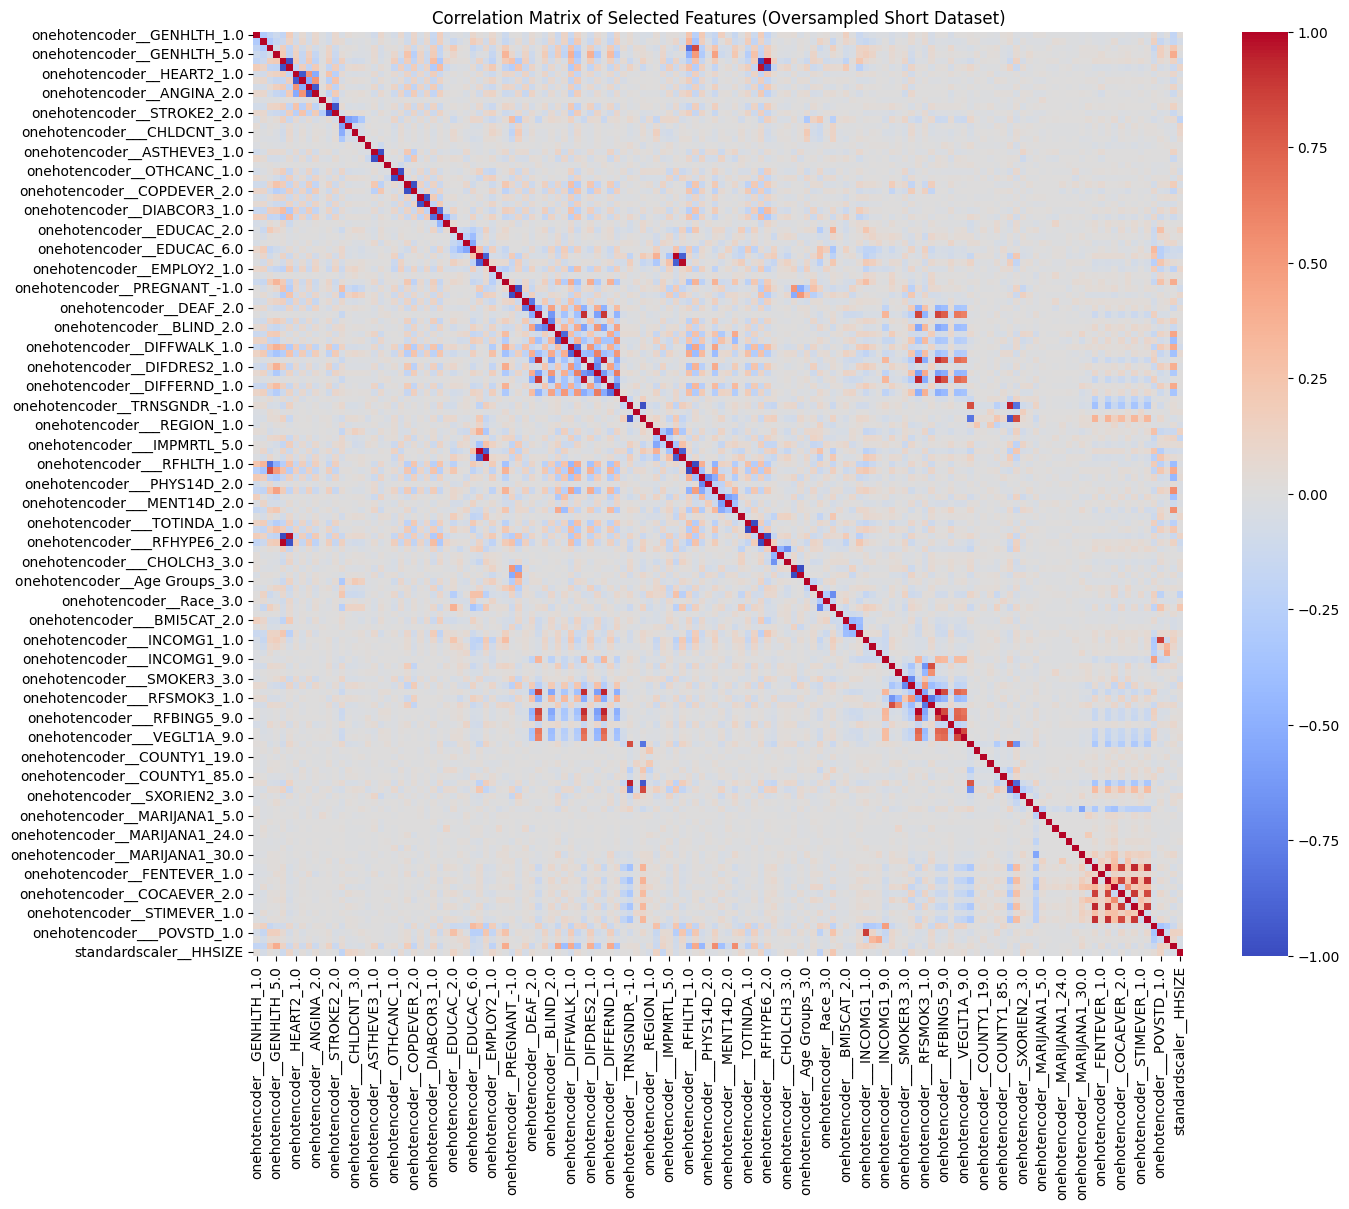

In [54]:
import pandas as pd
import numpy as np

# Convert the sparse matrix to a dense NumPy array
XR_dense = XR.toarray()

# Convert the dense NumPy array to a pandas DataFrame for easy correlation calculation
try:
    # Assuming feature_names2 corresponds to the columns in XRes2
    XR_df = pd.DataFrame(XR_dense, columns=feature_names2)
except NameError:
    print("Warning: feature_names2 not found. Using generic column names.")
    XRes2_df = pd.DataFrame(XR_dense)


# Calculate the correlation matrix
Corr_Matrix = XR_df.corr()

# Round the correlation matrix for display
Corr_Matrix_rounded = round(Corr_Matrix, 2)

# You can optionally visualize the correlation matrix using seaborn heatmap if it's not too large
# import seaborn as sns
# import matplotlib.pyplot as plt
#
plt.figure(figsize=(15, 12))
sns.heatmap(Corr_Matrix_rounded, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Selected Features (Oversampled Short Dataset)')
plt.show()

## **Basic model for Predictions**

In [55]:
dummy_clf = DummyClassifier(strategy = 'most_frequent')
dummy_clf.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

In [56]:
baseline_accuracy = dummy_clf.score(X_test, y_test)
Accuracy ="{:.2f}%".format(baseline_accuracy * 100)
print("Baseline Accuracy (FULL): ", Accuracy)


Baseline Accuracy (FULL):  49.68%


## **Running LogisticRegression on the Dataset**

In [63]:
LogR1 = LogisticRegressionCV()
LogR1.fit(X_train, y_train)

LogR1_accuracy = LogR1.score(X_train, y_train)
accuracy ="{:.2f}%".format(LogR1_accuracy * 100)
precisiona = precision_score(y_test, preds, pos_label=1)
precision = precisiona*100
recalla = recall_score(y_test, preds, pos_label=1)
recall = recalla*100
print("LogR1 Training Accuracy FULL: ", accuracy)
print(f'Precision: {precision:.2f}%')
print(f'Recall: {recall:.2f}%')



LogisticRegressionCV()

LogR1 Training Accuracy FULL:  78.31%
Precision: 77.70%
Recall: 76.17%


In [64]:
# Select features using the training set only
selector = SelectKBest(k=20)
X_train_selected = selector.fit_transform(X_train, y_train)

# fit again a simple logistic regression
LogR1 = LogisticRegressionCV()
LogR1.fit(X_train, y_train)
# select the same features on the test set, predict, and get the test accuracy:
X_test_selected = selector.transform(X_test)
y_pred = LogR1.predict(X_test)
accuracy= accuracy_score(y_test, y_pred)
x_labels = [original_feature_names[i] for i in selector.get_support(indices=True)]

accuracy2 ="{:.2f}%".format(accuracy * 100)
print("LogR1 Test Accuracy FULL: ", accuracy2)

LogisticRegressionCV()

LogR1 Test Accuracy FULL:  77.30%


## **Testing of Models**

In [65]:
# Initialize the results DataFrame to collect each Model's performance measures

results = pd.DataFrame(columns = ['Model', 'Train Time', 'Train Accuracy', 'Test Accuracy', 'Test Time', 'Precission', 'Recall', 'Inference Time', 'Best Parameters'])


In [66]:
# Create Model library for analysis
model = {'Logistic Regression': LogisticRegression(),
         'KNN' : KNeighborsClassifier(),
         'Decision Tree': DecisionTreeClassifier(),
        'SVM': SVC(),
         'RDM': RandomForestClassifier()}

In [ ]:
# create a teste loop to run every model on the short data set
for model_name, model in model.items():
    model.fit(X_train, y_train)

    # Calculate the accuracy, test time & best parameters for each model
    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)

    best_params = model.get_params()


    # Model predictions to calculate recall
    y_pred = model.predict(X_test)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)

  ## Create a temporary DataFrame for the current model and row
    new_row = pd.DataFrame([{
        'Model': model_name,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'Precission': precision,
        'Recall': recall,
        "Best Parameters": best_params
    }])


     # Use pd.concat to add the new row to the results DataFrame
    results = pd.concat([results, new_row], ignore_index=True)


LogisticRegression()

KNeighborsClassifier()

DecisionTreeClassifier()

SVC()

RandomForestClassifier()

In [ ]:
results.head()

,Model,Train Time,Train Accuracy,Test Accuracy,Test Time,Precission,Recall,Inference Time,Best Parameters
0,Logistic Regression,NaN,0.773785,0.768300,NaN,0.777503,0.747475,NaN,"{'C': 1.0, 'class_weight': None, 'dual': False..."
1,KNN,NaN,0.845901,0.789847,NaN,0.706508,0.986928,NaN,"{'algorithm': 'auto', 'leaf_size': 30, 'metric..."
2,Decision Tree,NaN,1.000000,0.875148,NaN,0.862903,0.890077,NaN,"{'ccp_alpha': 0.0, 'class_weight': None, 'crit..."
3,SVM,NaN,0.923203,0.888430,NaN,0.899571,0.872846,NaN,"{'C': 1.0, 'break_ties': False, 'cache_size': ..."
4,RDM,NaN,1.000000,0.930047,NaN,0.951875,0.904932,NaN,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."


<Axes: xlabel='Model', ylabel='Test Accuracy'>

Text(0.5, 1.0, 'Model Test Accuracy Comparison')

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Logistic Regression'),
  Text(1, 0, 'KNN'),
  Text(2, 0, 'Decision Tree'),
  Text(3, 0, 'SVM'),
  Text(4, 0, 'RDM')])

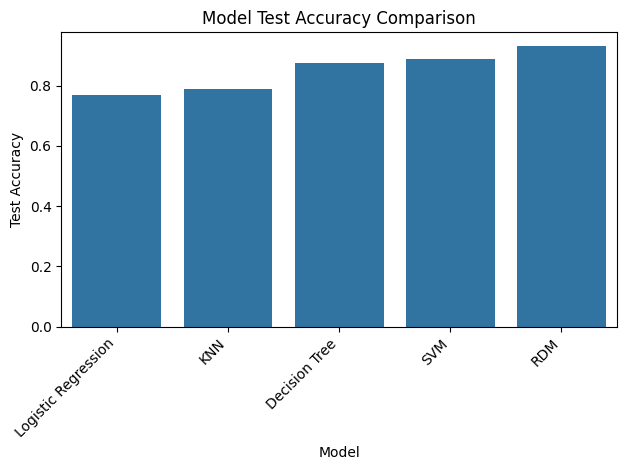

In [ ]:
sns.barplot(x='Model', y='Test Accuracy', data=results)
plt.title('Model Test Accuracy Comparison')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **Implementing Survey Weights**

In [ ]:
import statsmodels.formula.api as smf
from statsmodels.survey.survey_design import SurveyDesign
from statsmodels.survey.survey_model import SurveyOLS


In [ ]:
design = SurveyDesign(
    weights=df['_LLCPWT'],
    strata=df['_STSTR'],
    cluster=df['_PSU'],
    data=df
)
